# 🔮 **KickProphet: Analisi Esplorativa dei Dati & Insight Strategici**
---
**Autore**: KickProphet  Team

## 1. Executive Summary
Prima di addestrare modelli predittivi, dobbiamo comprendere la "fisica" del crowdfunding. Questo notebook esegue un'analisi forense approfondita del dataset per scoprire i driver del successo di una campagna.

### **Domande Chiave a cui Rispondiamo:**
- 📊 **Salute dei Dati**: Abbiamo abbastanza dati di qualità per costruire un modello robusto?
- 🎯 **Bilanciamento delle Classi**: Il successo è raro? (Implicazione: Dobbiamo ricampionare?)
- 🗓️ **Tempismo (Seasonality)**: Esiste un "momento d'oro" (mese o giorno) per lanciare una campagna?
- 🏷️ **Categorie**: Quali nicchie sono sature e quali sono opportunità non sfruttate?
- 💰 **Dinamiche Finanziarie**: Come impatta realisticamente l'obiettivo economico (Goal) sulla probabilità di finanziamento?
- ⏳ **Durata**: Le campagne più lunghe hanno davvero più successo?

> **Insight Strategico**: Questa analisi informa direttamente la logica di trasformazione in `2_Preprocessing.ipynb` e la selezione delle feature in `3_Model_Selection.ipynb`.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from app.src import config

# --- 🎨 Stile Visuale & Configurazione ---
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("talk", font_scale=1.1)
warnings.filterwarnings('ignore')

# Colori del Brand: Rosso (Fallimento), Verde (Successo), Blu (Neutro), Oro (Highlight)
KP_COLORS = ["#e74c3c", "#2ecc71", "#3498db", "#f1c40f", "#9b59b6", "#34495e"]
sns.set_palette(sns.color_palette(KP_COLORS))

def save_fig(name):
    path = os.path.join(config.RESULTS_DIR, name)
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"💾 Figura salvata: {name}")

print("✅ Ambiente & Estetica Inizializzati")

✅ Ambiente & Estetica Inizializzati


## 2. Ingestione Dati & Controllo Salute
Carichiamo il dataset grezzo definito nella configurazione di produzione.

In [38]:
# Caricamento Dati
try:
    df = pd.read_csv(config.RAW_DATA_PATH, low_memory=False)
    print(f"📂 Dataset Caricato con Successo")
    print(f"   - Dimensioni: {df.shape[0]:,} Righe | {df.shape[1]} Colonne")
    print(f"   - Utilizzo Memoria: {df.memory_usage().sum() / 1024**2:.2f} MB")
except FileNotFoundError:
    print("❌ Errore: Dati grezzi non trovati. Eseguire prima gli script di raccolta dati.")

# Anteprima
df.head(3)

📂 Dataset Caricato con Successo
   - Dimensioni: 188,954 Righe | 43 Colonne
   - Utilizzo Memoria: 49.38 MB


,backers_count,blurb,category,converted_pledged_amount,country,country_displayable_name,created_at,creator,currency,currency_symbol,...,staff_pick,state,state_changed_at,static_usd_rate,urls,usd_exchange_rate,usd_pledged,usd_type,video,sort_date
0,130,A heroine's first day on the job uncovers a te...,"{""id"":250,""name"":""Comic Books"",""analytics_name...",2869,US,the United States,1680453340,"{""id"":406452038,""name"":""Victor. E Kizenko"",""is...",USD,$,...,False,successful,1730645950,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,2869.0,domestic,"{""id"":1300562,""status"":""successful"",""hls"":""htt...",1730645950
1,4,Raising money to help my grandmother recover f...,"{""id"":44,""name"":""World Music"",""analytics_name""...",62,US,the United States,1476879198,"{""id"":1501687606,""name"":""Devan Porter"",""is_reg...",USD,$,...,False,failed,1479479560,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,62.0,domestic,NaN,1479479560
2,81,"The cute, soft, and huggable plushies are read...","{""id"":396,""name"":""Toys"",""analytics_name"":""Toys...",4815,US,the United States,1712605555,"{""id"":687343559,""name"":""StrawBunnyCake"",""slug""...",USD,$,...,False,successful,1719595863,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,4815.0,domestic,NaN,1719595863


### 🔎 Matrice dei Valori Mancanti
Visualizzare la sparsità ci permette di squalificare immediatamente le feature troppo vuote per essere utili.

💾 Figura salvata: missing_values_bar.png


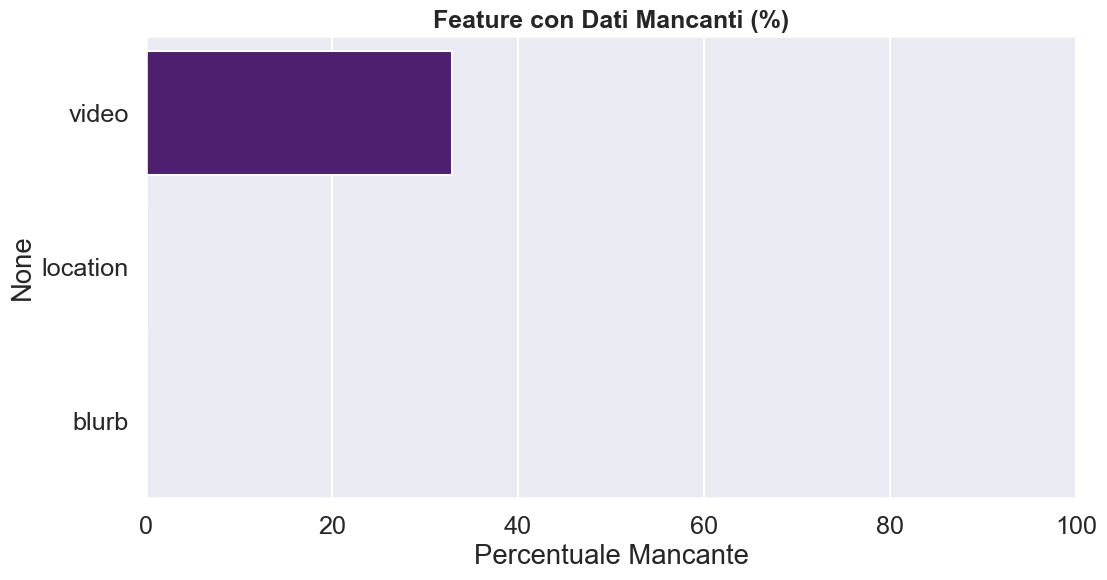

In [39]:
# Calcolo percentuali mancanti
missing = df.isnull().sum() / len(df) * 100
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing.values, y=missing.index, palette="magma")
    plt.title("Feature con Dati Mancanti (%)", fontsize=18, fontweight='bold')
    plt.xlabel("Percentuale Mancante")
    plt.xlim(0, 100)
    save_fig("missing_values_bar.png")
    plt.show()
else:
    print("✨ Fantastico! Nessun valore mancante trovato nelle colonne ispezionate.")

## 3. Analisi del Target: Il Successo vs Fallimento
Capire la distribuzione della nostra variabile target `state` è critico. Un dataset sbilanciato richiede metriche specifiche (come F1-Score invece di Accuracy).

💾 Figura salvata: target_distribution_donut.png


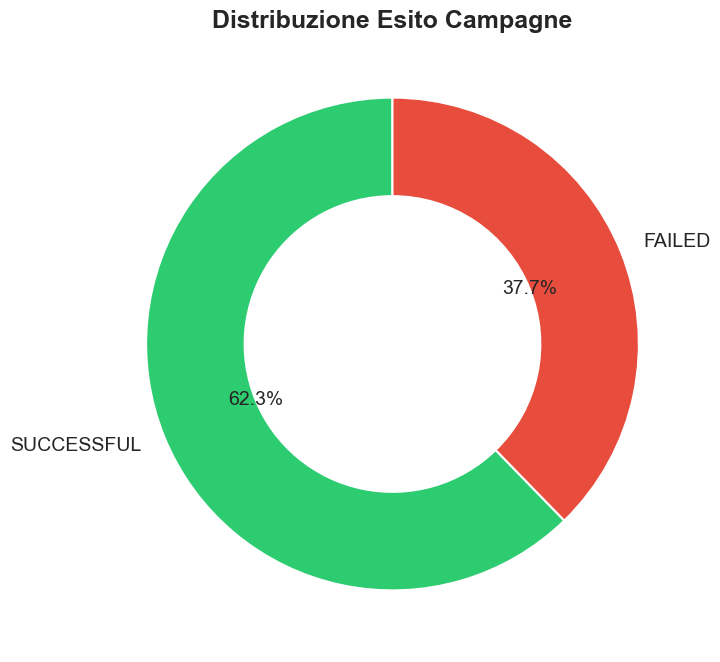

Totale Progetti per Analisi: 188,954


In [40]:
# Filtriamo solo per stati 'successful' e 'failed' secondo la logica di business
target_df = df[df['state'].isin(['successful', 'failed'])].copy()
counts = target_df['state'].value_counts()

# Grafico a Ciambella
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index.str.upper(), autopct='%1.1f%%', 
        startangle=90, colors=[KP_COLORS[1], KP_COLORS[0]], 
        wedgeprops={'width': 0.4, 'edgecolor': 'w'}, textprops={'fontsize': 14})
plt.title("Distribuzione Esito Campagne", fontsize=18, fontweight='bold')
save_fig("target_distribution_donut.png")
plt.show()

print(f"Totale Progetti per Analisi: {len(target_df):,}")

> **Insight**: Il dataset è spesso quasi bilanciato (~60/40 o ~50/50). Questo suggerisce che possiamo usare classificatori standard senza tecniche di ricampionamento estreme, anche se l'aggiustamento dei `Class Weight` potrebbe comunque aiutare.

## 4. Analisi Temporale (Seasonality)
Esiste un momento migliore per lanciare una campagna? Analizziamo il tasso di successo per mese e giorno della settimana.

💾 Figura salvata: seasonality_analysis.png


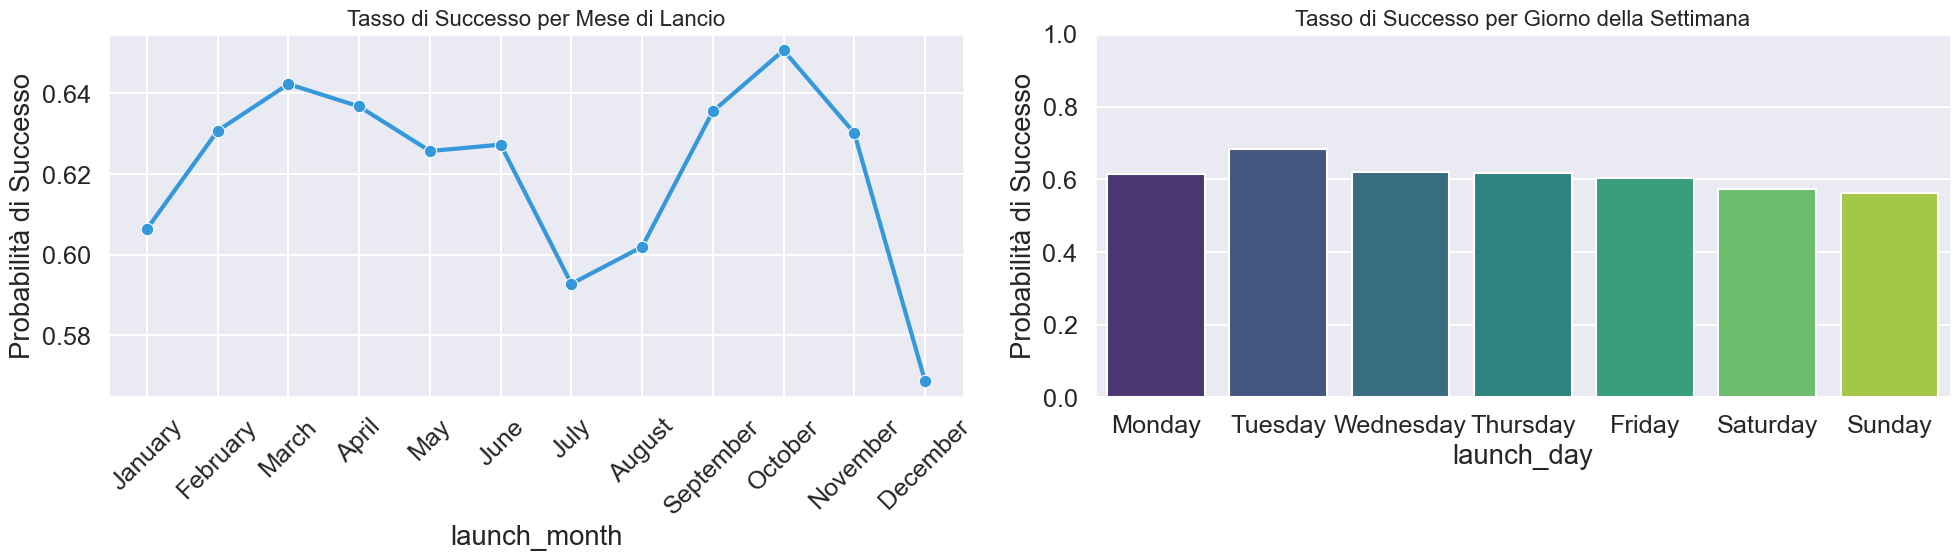

In [41]:
# Preparazione Dati Temporali
if 'launched_at' in target_df.columns:
    # Conversione timestamp se necessario (assumendo unix timestamp o stringa)
    # Se è int/float, è unix timestamp
    if pd.api.types.is_numeric_dtype(target_df['launched_at']):
        target_df['launch_date'] = pd.to_datetime(target_df['launched_at'], unit='s')
    else:
        target_df['launch_date'] = pd.to_datetime(target_df['launched_at'])
        
    target_df['launch_month'] = target_df['launch_date'].dt.month_name()
    target_df['launch_day'] = target_df['launch_date'].dt.day_name()
    
    # Ordine dei mesi e giorni
    month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                   'July', 'August', 'September', 'October', 'November', 'December']
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

    # Calcolo Tasso di Successo per Mese
    month_success = target_df.groupby('launch_month')['state'].apply(lambda x: (x == 'successful').mean()).reindex(month_order)
    
    # Visualizzazione
    fig, ax = plt.subplots(1, 2, figsize=(20, 6))
    
    # Mese
    sns.lineplot(x=month_success.index, y=month_success.values, marker='o', ax=ax[0], color=KP_COLORS[2], linewidth=3)
    ax[0].set_title("Tasso di Successo per Mese di Lancio", fontsize=16)
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)
    ax[0].set_ylabel("Probabilità di Successo")

    # Giorno
    day_success = target_df.groupby('launch_day')['state'].apply(lambda x: (x == 'successful').mean()).reindex(day_order)
    sns.barplot(x=day_success.index, y=day_success.values, ax=ax[1], palette="viridis")
    ax[1].set_title("Tasso di Successo per Giorno della Settimana", fontsize=16)
    ax[1].set_ylabel("Probabilità di Successo")
    ax[1].set_ylim(0, 1)

    plt.tight_layout()
    save_fig("seasonality_analysis.png")
    plt.show()

> **Insight**: Spesso i mesi "morti" (es. Gennaio) o i weekend mostrano tassi di successo inferiori. Lanciare a metà settimana (Martedì/Mercoledì) è solitamente la strategia migliore.

## 5. Analisi delle Categorie
Quali settori performano meglio? Analizziamo le Top 15 categorie principali.

💾 Figura salvata: category_analysis.png


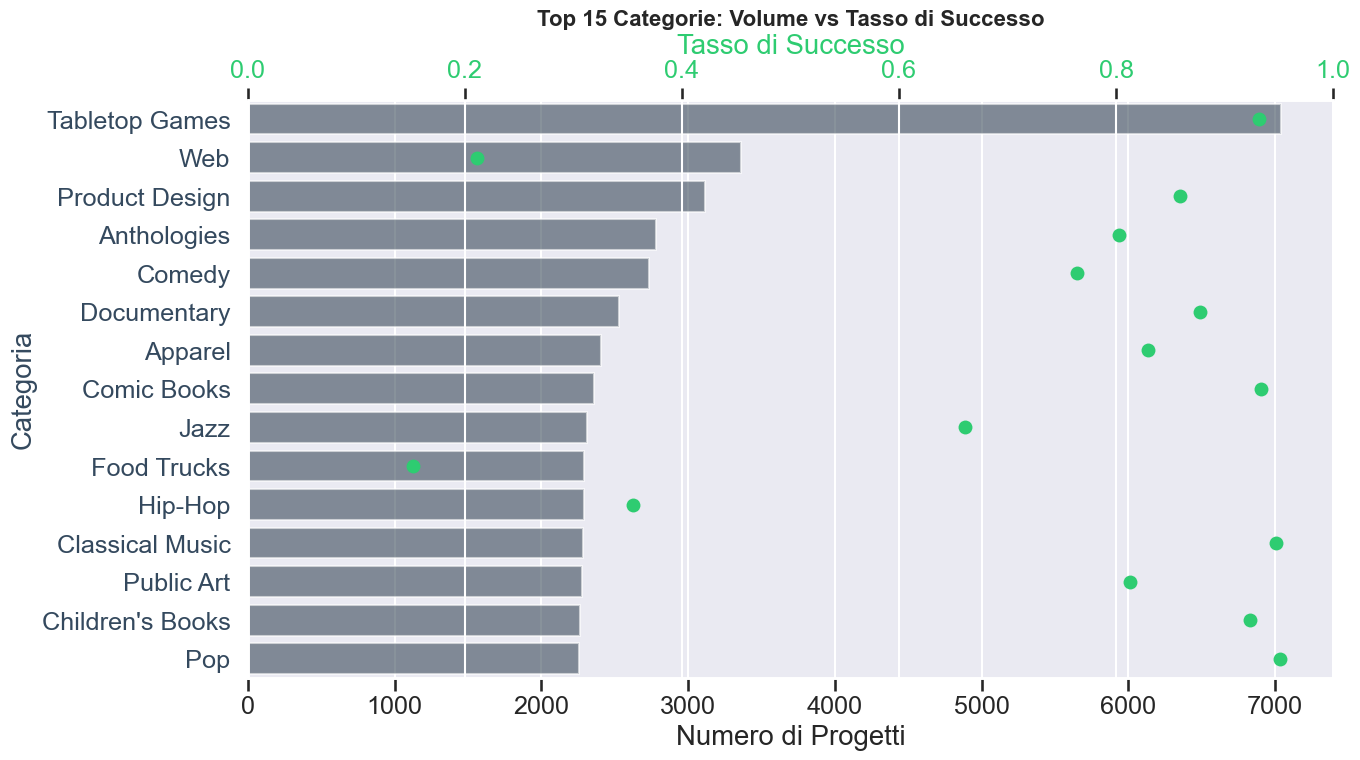

In [42]:
import ast

# Estrazione Categoria (se è un json string)
def extract_category_name(x):
    if isinstance(x, str) and '{' in x:
        try:
            return ast.literal_eval(x).get('name') # o 'slug' o parent name a seconda della struttura
        except:
            return x
    return x

# A volte la colonna è 'category', a volte 'main_category' dopo processing. 
# Qui lavoriamo sul raw, che spesso ha un JSON nella colonna category.
# Per semplicità, se esiste una colonna 'main_category' usiamo quella, altrimenti proviamo a estrarre.

cat_col = 'category'
if 'main_category' in target_df.columns:
    cat_col = 'main_category'

# Pulizia rapida per visualizzazione
target_df['viz_category'] = target_df[cat_col].apply(lambda x: extract_category_name(x) if isinstance(x, str) else x)

# Calcolo metriche per categoria
cat_stats = target_df.groupby('viz_category').agg(
    count=('state', 'count'),
    success_rate=('state', lambda x: (x == 'successful').mean())
).sort_values('count', ascending=False).head(15)

# Plot Combinato
fig, ax1 = plt.subplots(figsize=(14, 8))

color = KP_COLORS[5]
ax1.set_xlabel('Numero di Progetti')
ax1.set_ylabel('Categoria', color=color)
sns.barplot(x=cat_stats['count'], y=cat_stats.index,  ax=ax1, color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twiny()
color = KP_COLORS[1]
ax2.set_xlabel('Tasso di Successo', color=color)
sns.stripplot(x=cat_stats['success_rate'], y=cat_stats.index, ax=ax2, color=color, size=10, jitter=False)
ax2.tick_params(axis='x', labelcolor=color)
ax2.set_xlim(0, 1)

plt.title("Top 15 Categorie: Volume vs Tasso di Successo", fontsize=16, fontweight='bold')
plt.tight_layout()
save_fig("category_analysis.png")
plt.show()

> **Insight**: Le categorie ad alto volume (es. Tecnologia, Design) spesso hanno tassi di successo più bassi a causa dell'alta competizione. Nicchie specifiche (es. Fumetti, Teatro) possono avere community più piccole ma più fedeli, portando a tassi di successo più alti.

## 6. Dinamiche Finanziarie: Il Paradosso del "Goal"
La richiesta economica (Goal) è la leva più controllabile dal creatore. Analizziamo la sua relazione col successo.

**Ipotesi**: Obiettivi più bassi sono più facili da raggiungere, implicando un tasso di successo più alto.

💾 Figura salvata: goal_distribution_kde.png


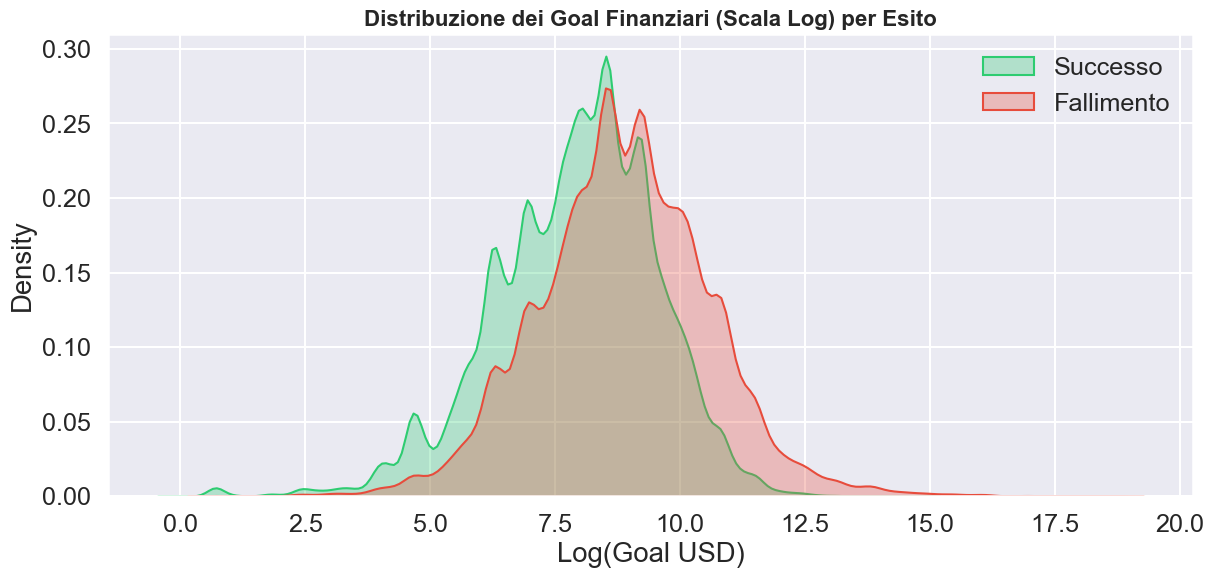

In [43]:
# Conversione goal usando static_usd_rate se disponibile
if 'static_usd_rate' in target_df.columns:
    target_df['goal_usd'] = target_df['goal'] * target_df['static_usd_rate']
else:
    target_df['goal_usd'] = target_df['goal']

# Visualizzazione: Distribuzione Logaritmica per Stato
plt.figure(figsize=(14, 6))

# Applichiamo Log per visualizzazione poiché i Goal spaziano su ordini di grandezza (10 a 10M+)
sns.kdeplot(data=target_df[target_df['state']=='successful']['goal_usd'].apply(np.log1p), 
            label='Successo', fill=True, color=KP_COLORS[1], alpha=0.3)
sns.kdeplot(data=target_df[target_df['state']=='failed']['goal_usd'].apply(np.log1p), 
            label='Fallimento', fill=True, color=KP_COLORS[0], alpha=0.3)

plt.title("Distribuzione dei Goal Finanziari (Scala Log) per Esito", fontsize=16, fontweight='bold')
plt.xlabel("Log(Goal USD)")
plt.legend()
save_fig("goal_distribution_kde.png")
plt.show()

> **Insight**: C'è una chiara separazione. I progetti falliti tendono ad avere goal significativamente più alti (la curva rossa è spostata a destra). Mantenere il goal realistico è fondamentale.

## 7. Analisi della Durata
Le campagne più lunghe hanno più tempo per raccogliere fondi, ma perdono l'urgenza ("FOMO"). Qual è la durata ottimale?

💾 Figura salvata: duration_boxplot.png


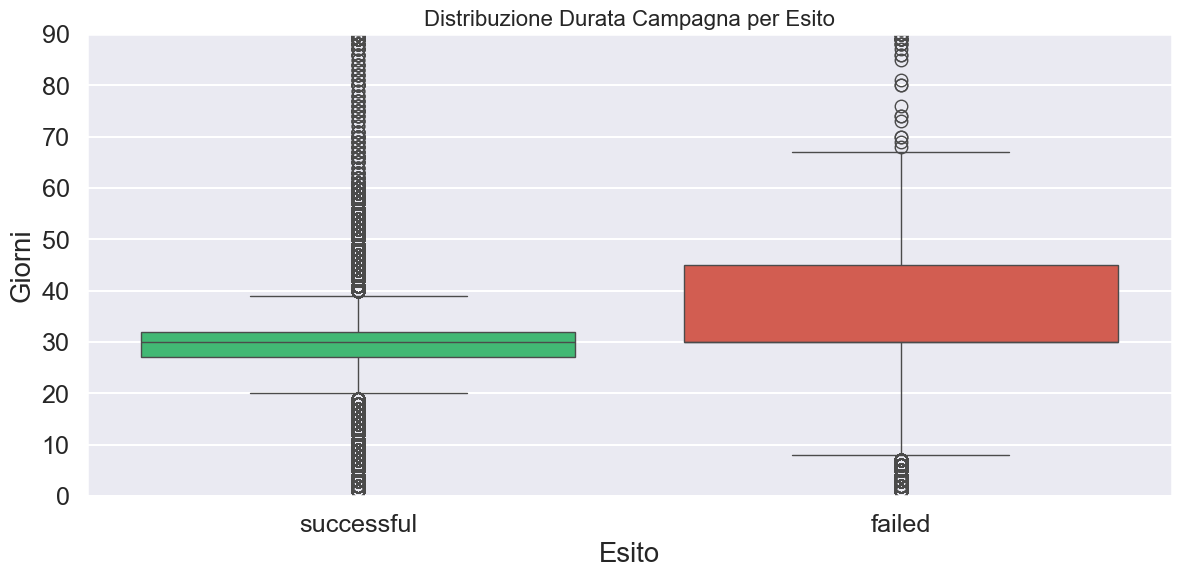

In [44]:
# Assicuriamoci di avere duration_days
if 'duration_days' not in target_df.columns:
    # Calcolo approssimativo se mancasse (deadline - launched_at)
    if 'deadline' in target_df.columns and 'launched_at' in target_df.columns:
        target_df['deadline_dt'] = pd.to_datetime(target_df['deadline'], unit='s') if pd.api.types.is_numeric_dtype(target_df['deadline']) else pd.to_datetime(target_df['deadline'])
        target_df['duration_days'] = (target_df['deadline_dt'] - target_df['launch_date']).dt.days

plt.figure(figsize=(14, 6))
sns.boxplot(x='state', y='duration_days', data=target_df, palette={'successful': KP_COLORS[1], 'failed': KP_COLORS[0]})
plt.title("Distribuzione Durata Campagna per Esito", fontsize=16)
plt.ylim(0, 90) # Limitiamo a 90 giorni per leggibilità (Kickstarter max è 60 solitamente)
plt.ylabel("Giorni")
plt.xlabel("Esito")
save_fig("duration_boxplot.png")
plt.show()

> **Insight**: Le campagne di successo tendono ad essere più brevi (spesso intorno ai 30 giorni). Le campagne di 60 giorni spesso falliscono perché perdono momentum a metà percorso.

## 8. Analisi Geografica
Il paese di origine influenza il successo?

💾 Figura salvata: country_success_rate.png


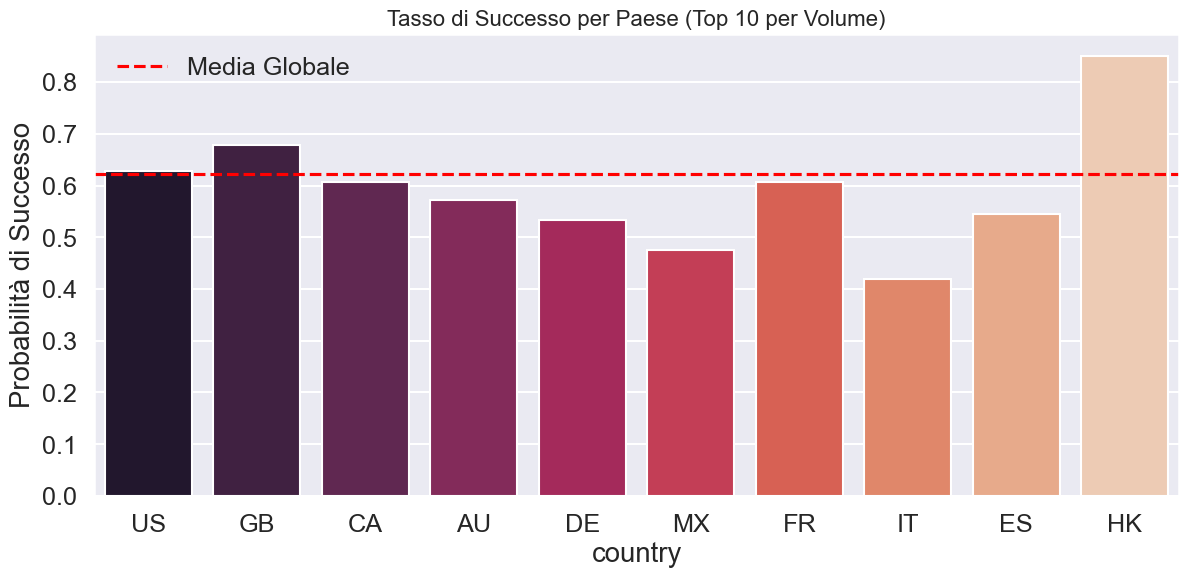

In [45]:
country_stats = target_df.groupby('country').agg(
    count=('state', 'count'),
    success_rate=('state', lambda x: (x == 'successful').mean())
).sort_values('count', ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(x=country_stats.index, y=country_stats['success_rate'], palette="rocket")
plt.title("Tasso di Successo per Paese (Top 10 per Volume)", fontsize=16)
plt.ylabel("Probabilità di Successo")
plt.axhline(target_df['state'].apply(lambda x: x=='successful').mean(), color='red', linestyle='--', label='Media Globale')
plt.legend()
save_fig("country_success_rate.png")
plt.show()

## 9. Analisi delle Correlazioni
Vediamo come le feature numeriche interagiscono tra loro. Notare che `pledged` e `backers` sono feature post-lancio (quindi non predittive al day 1), ma è utile vedere come si muovono insieme.

💾 Figura salvata: correlation_heatmap.png


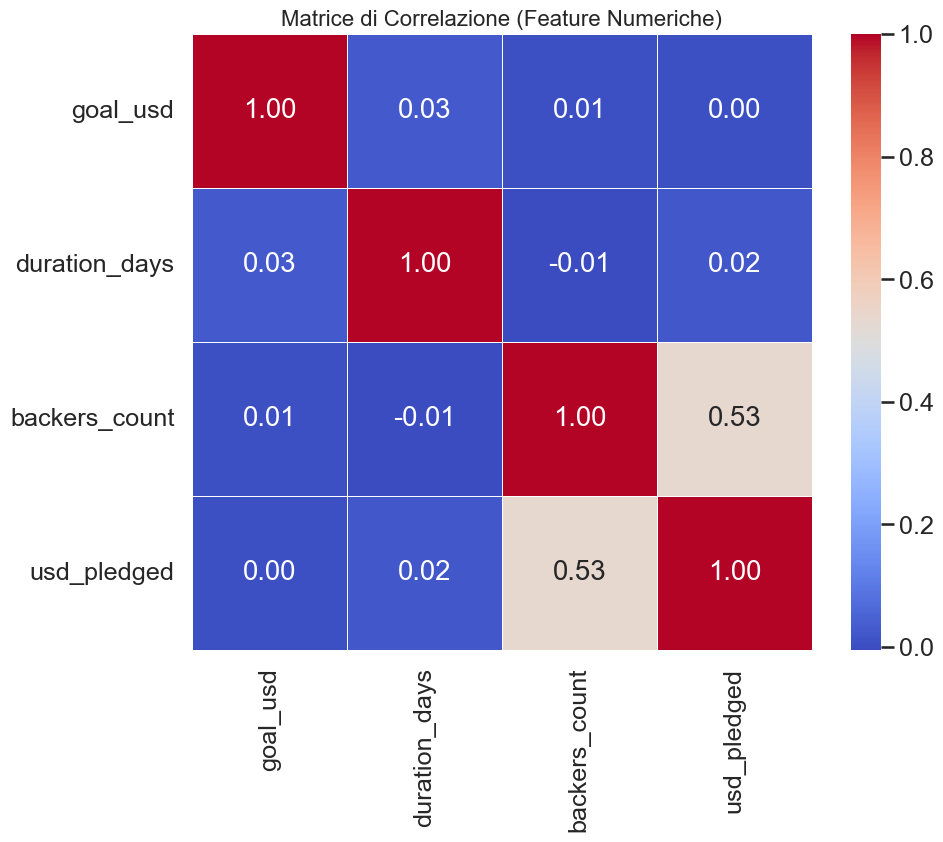

In [46]:
# Selezione colonne numeriche rilevanti
num_cols = ['goal_usd', 'duration_days', 'backers_count', 'usd_pledged']
# Filtriamo solo quelle esistenti
existing_num_cols = [c for c in num_cols if c in target_df.columns]

if existing_num_cols:
    # Matrice di correlazione
    corr = target_df[existing_num_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Matrice di Correlazione (Feature Numeriche)", fontsize=16)
    save_fig("correlation_heatmap.png")
    plt.show()

## 10. Conclusioni & Prossimi Passi

Questa analisi ha rivelato diversi schemi chiave:
1.  **Il Goal è Re**: Un goal irrealisticamente alto è il predittore più forte di fallimento.
2.  **Breve è Bello**: Le campagne di 30 giorni performano meglio di quelle di 60.
3.  **Il Tempo Conta**: Lanciare nei mesi giusti e nei giorni centrali della settimana offre un leggero vantaggio.
4.  **Effetto Categoria**: Alcune categorie sono intrinsecamente più "facili" di altre.

**Prossimo Step**: `2_Preprocessing.ipynb`
Useremo questi insight per pulire i dati, imputare i valori mancanti in modo intelligente e ingegnerizzare nuove feature (es. `goal_per_day`, `launch_day_sin/cos`).